In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
df = pd.read_csv('processed_hourly_energy.csv')
df.head()


,Appliance Type,timestamp,Energy Consumption (kWh),Energy_scaled
0,Air Conditioning,2023-01-01 00:00:00,4.42,0.155360
1,Air Conditioning,2023-01-01 01:00:00,7.61,0.267487
2,Air Conditioning,2023-01-01 02:00:00,14.80,0.520211
3,Air Conditioning,2023-01-01 03:00:00,4.19,0.147276
4,Air Conditioning,2023-01-01 04:00:00,10.68,0.375395


In [ ]:
hourly_df = df.copy()


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['weekday'] = df['timestamp'].dt.weekday


In [ ]:
# Lag features (previous time steps)
df['lag_1'] = df['Energy Consumption (kWh)'].shift(1)
df['lag_24'] = df['Energy Consumption (kWh)'].shift(24)


In [ ]:
# Moving average feature
df['rolling_mean_24'] = (
    df['Energy Consumption (kWh)']
    .rolling(window=24)
    .mean()
)


In [ ]:
df = df.dropna()


In [ ]:
import os

base_path = "./processed"
os.makedirs(base_path, exist_ok=True)

os.makedirs(f"{base_path}/X_train", exist_ok=True)
os.makedirs(f"{base_path}/X_test", exist_ok=True)
os.makedirs(f"{base_path}/y_train", exist_ok=True)
os.makedirs(f"{base_path}/y_test", exist_ok=True)
os.makedirs(f"{base_path}/plots", exist_ok=True)


In [ ]:
appliances = hourly_df['Appliance Type'].unique()
print("Total appliances detected:", len(appliances))
print("Appliances:", appliances)


Total appliances detected: 10
Appliances: ['Air Conditioning' 'Computer' 'Dishwasher' 'Fridge' 'Heater' 'Lights'
 'Microwave' 'Oven' 'TV' 'Washing Machine']


In [ ]:
for appliance in appliances:
    print(f"\nProcessing appliance: {appliance}")

    appliance_df = hourly_df[
        hourly_df['Appliance Type'] == appliance
    ].copy()

    X = appliance_df[
        ['hour', 'day', 'weekday', 'lag_1', 'lag_24', 'rolling_mean_24']
    ]
    y = appliance_df['Energy Consumption (kWh)']

    split_idx = int(len(appliance_df) * 0.8)

    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    safe_name = appliance.replace(" ", "_")

    X_train.to_csv(f"{base_path}/X_train/X_train_{safe_name}.csv", index=False)
    X_test.to_csv(f"{base_path}/X_test/X_test_{safe_name}.csv", index=False)
    y_train.to_csv(f"{base_path}/y_train/y_train_{safe_name}.csv", index=False)
    y_test.to_csv(f"{base_path}/y_test/y_test_{safe_name}.csv", index=False)



Processing appliance: Air Conditioning

Processing appliance: Computer

Processing appliance: Dishwasher

Processing appliance: Fridge

Processing appliance: Heater

Processing appliance: Lights

Processing appliance: Microwave

Processing appliance: Oven

Processing appliance: TV

Processing appliance: Washing Machine


In [ ]:
!ls /content/appliance_datasets/X_train


X_train_Air_Conditioning.csv  X_train_Lights.csv
X_train_Computer.csv	      X_train_Microwave.csv
X_train_Dishwasher.csv	      X_train_Oven.csv
X_train_Fridge.csv	      X_train_TV.csv
X_train_Heater.csv	      X_train_Washing_Machine.csv


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for appliance in appliances:
    safe = appliance.replace(" ", "_")

    X_train = pd.read_csv(f"{base_path}/X_train/X_train_{safe}.csv")
    X_test  = pd.read_csv(f"{base_path}/X_test/X_test_{safe}.csv")
    y_train = pd.read_csv(
        f"{base_path}/y_train/y_train_{safe}.csv"
    ).values.ravel()
    y_test  = pd.read_csv(
        f"{base_path}/y_test/y_test_{safe}.csv"
    ).values.ravel()

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"{appliance} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")


Air Conditioning → MAE: 2.85, RMSE: 3.60
Computer → MAE: 0.99, RMSE: 1.24
Dishwasher → MAE: 1.04, RMSE: 1.30
Fridge → MAE: 0.27, RMSE: 0.34
Heater → MAE: 2.75, RMSE: 3.45
Lights → MAE: 0.98, RMSE: 1.21
Microwave → MAE: 1.02, RMSE: 1.28
Oven → MAE: 1.03, RMSE: 1.29
TV → MAE: 1.00, RMSE: 1.24
Washing Machine → MAE: 0.98, RMSE: 1.22


In [ ]:
X = df[['hour', 'day', 'weekday', 'lag_1', 'lag_24', 'rolling_mean_24']]
y = df['Energy Consumption (kWh)']



In [ ]:
train_size = int(len(df) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]


In [ ]:
import os

base_dir = "/content/appliance_datasets"

folders = [
    "X_train", "X_test",
    "y_train", "y_test"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

print("Folders created successfully")


Folders created successfully


In [ ]:
appliances = hourly_df['Appliance Type'].unique()
print("Total appliances:", len(appliances))
print(appliances)


Total appliances: 10
['Air Conditioning' 'Computer' 'Dishwasher' 'Fridge' 'Heater' 'Lights'
 'Microwave' 'Oven' 'TV' 'Washing Machine']


In [ ]:
for appliance in appliances:
    print(f"\nProcessing appliance: {appliance}")

    df_a = hourly_df[
        hourly_df['Appliance Type'] == appliance
    ].copy()

    X = df_a[
        ['hour', 'day', 'weekday', 'lag_1', 'lag_24', 'rolling_mean_24']
    ]
    y = df_a['Energy Consumption (kWh)']

    split_idx = int(len(df_a) * 0.7)   # ✅ 70% train, 30% test

    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    safe_name = appliance.replace(" ", "_")

    X_train.to_csv(f"{base_dir}/X_train/X_train_{safe_name}.csv", index=False)
    X_test.to_csv(f"{base_dir}/X_test/X_test_{safe_name}.csv", index=False)
    y_train.to_csv(f"{base_dir}/y_train/y_train_{safe_name}.csv", index=False)
    y_test.to_csv(f"{base_dir}/y_test/y_test_{safe_name}.csv", index=False)

print("\nAll appliance-wise CSV files saved successfully!")



Processing appliance: Air Conditioning

Processing appliance: Computer

Processing appliance: Dishwasher

Processing appliance: Fridge

Processing appliance: Heater

Processing appliance: Lights

Processing appliance: Microwave

Processing appliance: Oven

Processing appliance: TV

Processing appliance: Washing Machine

All appliance-wise CSV files saved successfully!


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)



MAE: 1.005003771245683
RMSE: 1.2594256610660912


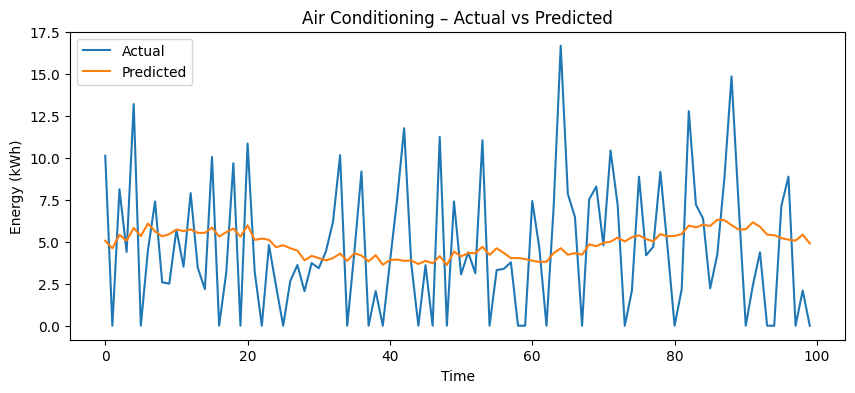

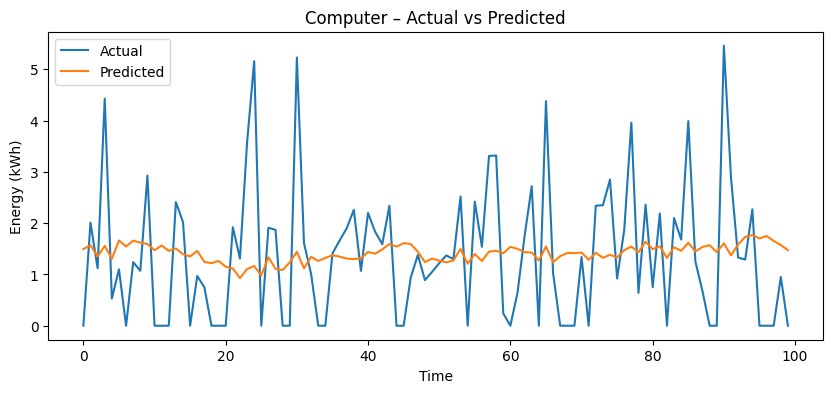

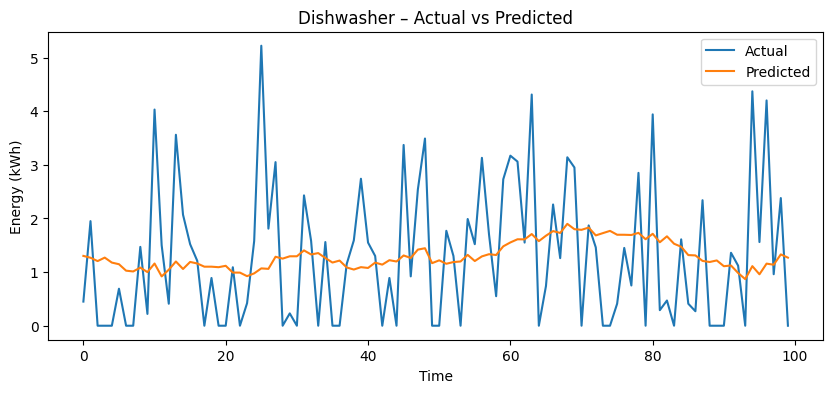

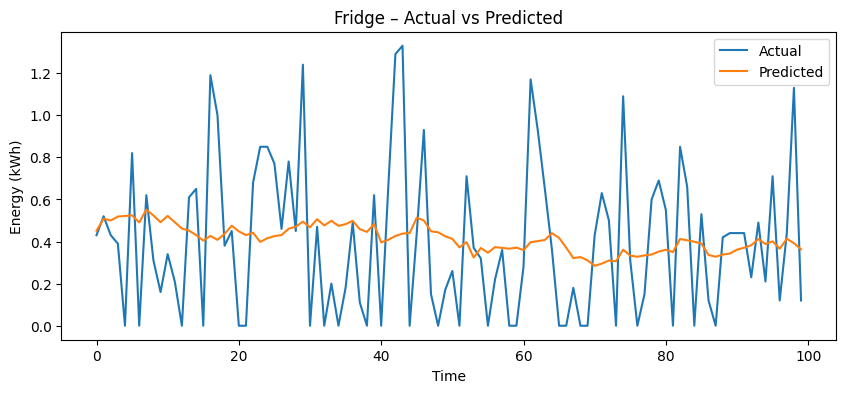

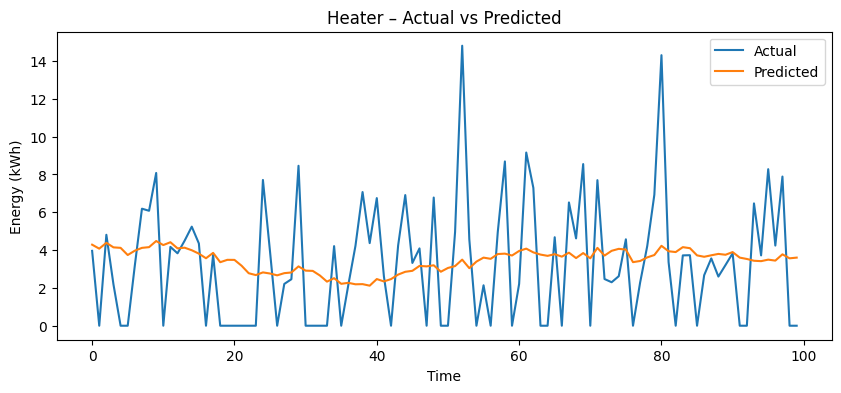

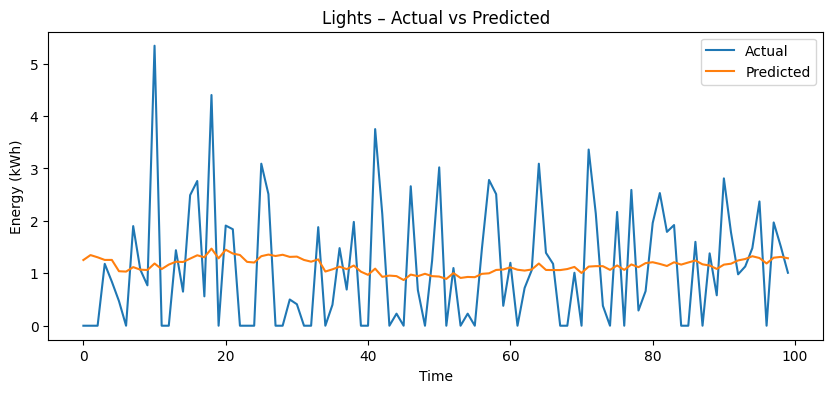

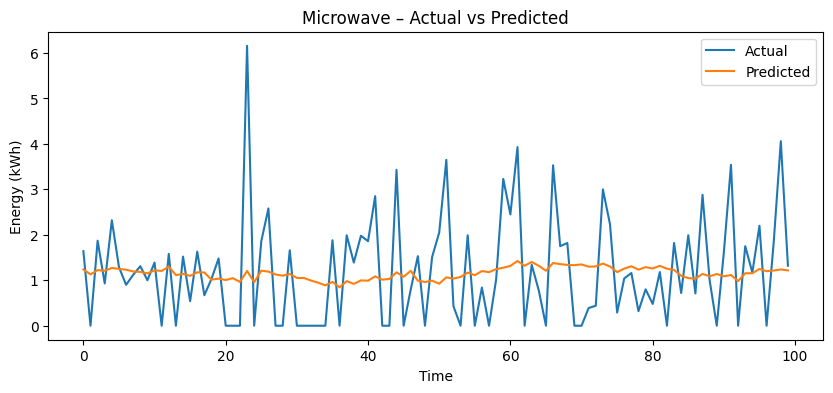

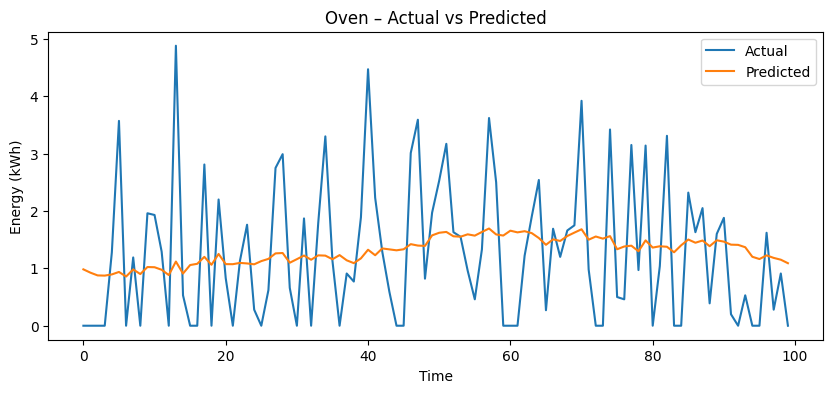

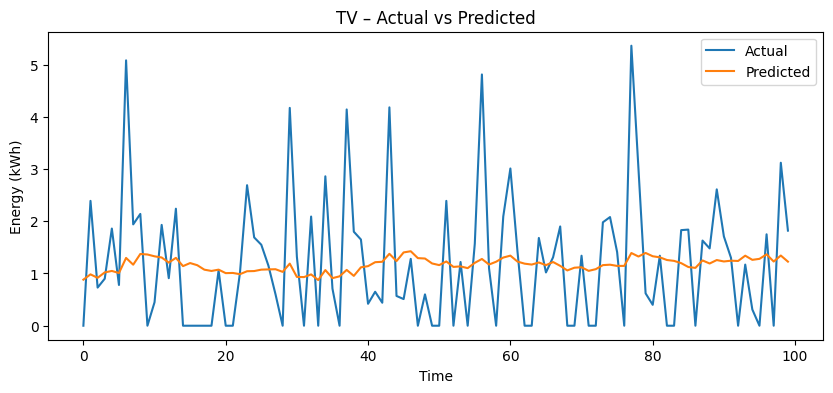

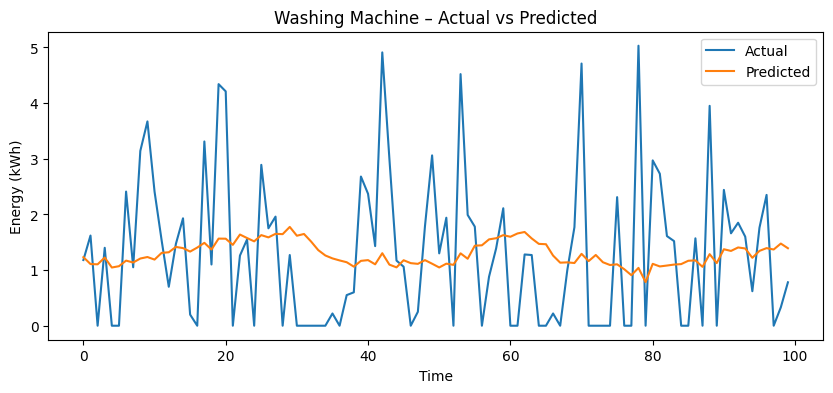

In [ ]:
import matplotlib.pyplot as plt

for appliance in appliances:
    safe = appliance.replace(" ", "_")

    X_test = pd.read_csv(f"{base_path}/X_test/X_test_{safe}.csv")
    y_test = pd.read_csv(
        f"{base_path}/y_test/y_test_{safe}.csv"
    ).values.ravel()

    model = LinearRegression()
    model.fit(
        pd.read_csv(f"{base_path}/X_train/X_train_{safe}.csv"),
        pd.read_csv(
            f"{base_path}/y_train/y_train_{safe}.csv"
        ).values.ravel()
    )

    y_pred = model.predict(X_test)

    plt.figure(figsize=(10,4))
    plt.plot(y_test[:100], label="Actual")
    plt.plot(y_pred[:100], label="Predicted")
    plt.title(f"{appliance} – Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Energy (kWh)")
    plt.legend()
    plt.show()


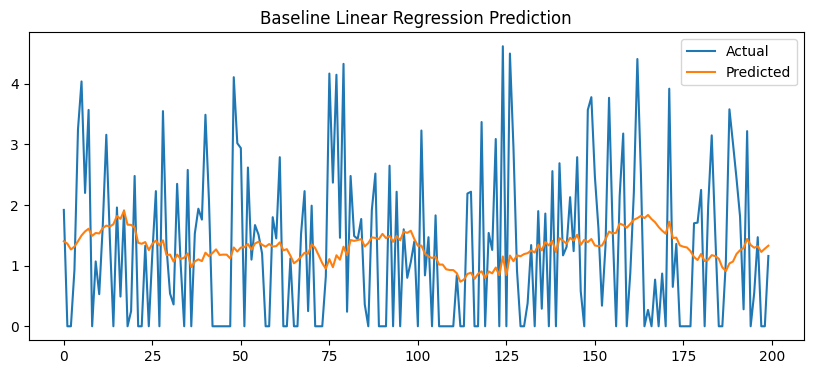

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title('Baseline Linear Regression Prediction')
plt.show()


In [ ]:
train_size = int(len(df) * 0.7)


In [ ]:
!zip -r appliance_datasets.zip /content/appliance_datasets


  adding: content/appliance_datasets/ (stored 0%)
  adding: content/appliance_datasets/X_train/ (stored 0%)
  adding: content/appliance_datasets/X_train/X_train_Dishwasher.csv (deflated 75%)
  adding: content/appliance_datasets/X_train/X_train_Fridge.csv (deflated 79%)
  adding: content/appliance_datasets/X_train/X_train_Oven.csv (deflated 76%)
  adding: content/appliance_datasets/X_train/X_train_Microwave.csv (deflated 76%)
  adding: content/appliance_datasets/X_train/X_train_Heater.csv (deflated 73%)
  adding: content/appliance_datasets/X_train/X_train_Air_Conditioning.csv (deflated 73%)
  adding: content/appliance_datasets/X_train/X_train_Lights.csv (deflated 76%)
  adding: content/appliance_datasets/X_train/X_train_Computer.csv (deflated 75%)
  adding: content/appliance_datasets/X_train/X_train_TV.csv (deflated 76%)
  adding: content/appliance_datasets/X_train/X_train_Washing_Machine.csv (deflated 76%)
  adding: content/appliance_datasets/y_train/ (stored 0%)
  adding: content/appl